In [19]:
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

In [20]:
IMAGE_SIZE = (150,150)
BATCH_SIZE = 32
SEED = 42

In [21]:
train_ds = keras.utils.image_dataset_from_directory(
    'rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="training",
    validation_split=0.2,
    seed=SEED
)

Found 2520 files belonging to 3 classes.
Using 2016 files for training.


In [5]:
val_ds = keras.utils.image_dataset_from_directory(
    'rps',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    subset="validation",
    validation_split=0.2,
    seed=SEED
)

Found 2520 files belonging to 3 classes.
Using 504 files for validation.


In [22]:
test_ds = keras.utils.image_dataset_from_directory(
    'rps-test-set',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 372 files belonging to 3 classes.


In [23]:
class_names = train_ds.class_names

In [24]:
class_names # p=0, r=1, s=2

['paper', 'rock', 'scissors']

In [25]:
num_classes = len(train_ds.class_names) # 3

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [27]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [28]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_aug,
    layers.Rescaling(1.0/255),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [29]:
# model.summary()

In [30]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 568ms/step - accuracy: 0.4122 - loss: 1.0493 - val_accuracy: 0.6290 - val_loss: 0.8057
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 580ms/step - accuracy: 0.6776 - loss: 0.7545 - val_accuracy: 0.8294 - val_loss: 0.4083
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.8576 - loss: 0.3714 - val_accuracy: 0.9663 - val_loss: 0.1331
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 510ms/step - accuracy: 0.9266 - loss: 0.2246 - val_accuracy: 0.9940 - val_loss: 0.0841
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - accuracy: 0.9469 - loss: 0.1721 - val_accuracy: 0.9940 - val_loss: 0.0546
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 513ms/step - accuracy: 0.9603 - loss: 0.1214 - val_accuracy: 0.9960 - val_loss: 0.0296
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 38s 614ms/step - accuracy: 0.9593 - loss: 0.1274 - val_accuracy: 0.9940 - val_loss: 0.0254
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 692ms/step - accuracy: 0.9653 - loss: 0.1043 - val_accu

In [32]:
test_loss, test_acc = model.evaluate(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9409 - loss: 0.0958


In [33]:
test_acc

0.9408602118492126

In [34]:
acc = history.history["accuracy"] # training acc
val_acc = history.history["val_accuracy"] # testing acc
loss = history.history["loss"] # traring loss
val_loss = history.history["val_loss"] # test loss

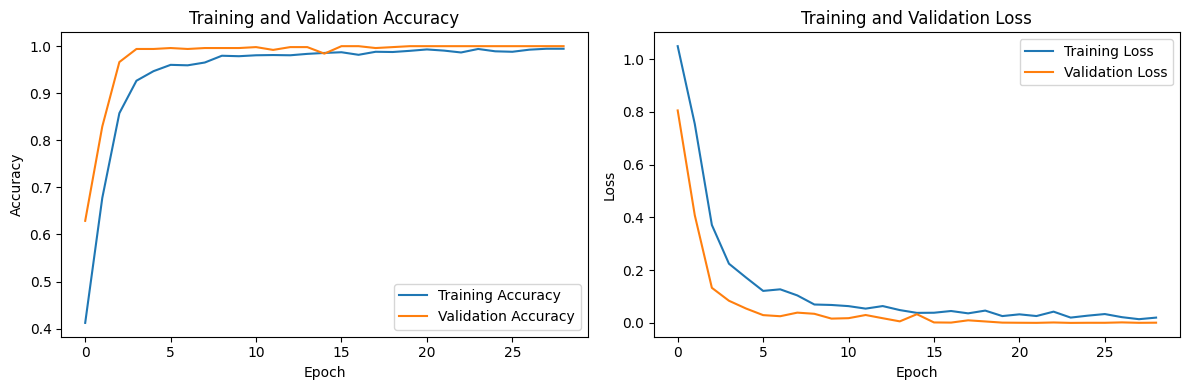

In [35]:
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


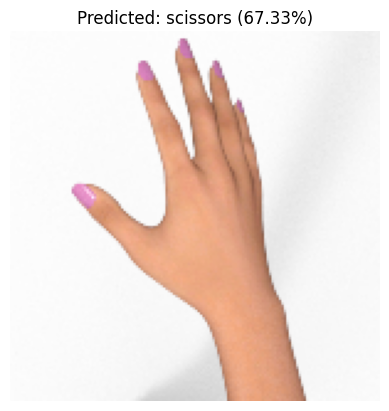

Predicted class: scissors
Confidence: 67.33%
All scores: {'paper': np.float32(0.32673407), 'rock': np.float32(1.8831845e-09), 'scissors': np.float32(0.67326593)}


In [37]:
import numpy as np

img_path = "rps-test-set/paper/testpaper01-00.png"

img = keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # add batch dim

preds = model.predict(img_array)
score = preds[0]

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.show()

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print(f"All scores: {dict(zip(class_names, score))}")

In [38]:
model.save("rps_cnn.keras")

In [41]:
# Single Image Classification                                                            
import numpy as np                                                                       

img_path = "rps/paper/paper01-000.png"                                  
                                                                                      
img = keras.utils.load_img(img_path, target_size=(150, 150))                             
img_array = keras.utils.img_to_array(img)                                                
img_array = tf.expand_dims(img_array, 0)  # add batch dim                                                                                                                       │
predictions = model.predict(img_array)                                                   
predicted_class = class_names[np.argmax(predictions[0])]                                  
confidence = 100 * np.max(predictions[0])  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
